In [18]:
import os
import pandas as pd

data_dir = "/kaggle/input/ravdess-emotional-speech-audio"

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

data = []

for actor_dir in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, actor_dir)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")
                emotion_code = parts[2]
                emotion_label = emotion_map.get(emotion_code, "unknown")
                parts = actor_dir.split("_")
                actor_id = parts[1]
                # Tạo đường dẫn đầy đủ đến tệp
                file_path = os.path.join(actor_path, file)
                data.append({
                    "file": file,
                    "emotion": emotion_label,
                    "actor_id": actor_id,
                    "file_path": file_path
                })
df = pd.DataFrame(data)

print(df.head())

df.to_csv("/kaggle/working/ravdess_labels.csv", index=False)



                       file    emotion actor_id  \
0  03-01-08-01-01-01-02.wav  surprised       02   
1  03-01-01-01-01-01-02.wav    neutral       02   
2  03-01-07-02-01-02-02.wav    disgust       02   
3  03-01-07-01-01-02-02.wav    disgust       02   
4  03-01-01-01-02-01-02.wav    neutral       02   

                                           file_path  
0  /kaggle/input/ravdess-emotional-speech-audio/A...  
1  /kaggle/input/ravdess-emotional-speech-audio/A...  
2  /kaggle/input/ravdess-emotional-speech-audio/A...  
3  /kaggle/input/ravdess-emotional-speech-audio/A...  
4  /kaggle/input/ravdess-emotional-speech-audio/A...  


In [19]:
print(df.shape)


(1440, 4)


In [20]:
print(df.dtypes)

file         object
emotion      object
actor_id     object
file_path    object
dtype: object


In [21]:
print(df.nunique())

file         1440
emotion         8
actor_id       24
file_path    1440
dtype: int64


In [22]:
print(df.describe())

                            file    emotion actor_id  \
count                       1440       1440     1440   
unique                      1440          8       24   
top     03-01-08-01-01-01-02.wav  surprised       02   
freq                           1        192       60   

                                                file_path  
count                                                1440  
unique                                               1440  
top     /kaggle/input/ravdess-emotional-speech-audio/A...  
freq                                                    1  


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file       1440 non-null   object
 1   emotion    1440 non-null   object
 2   actor_id   1440 non-null   object
 3   file_path  1440 non-null   object
dtypes: object(4)
memory usage: 45.1+ KB
None


In [24]:
print(df.isnull().sum())

file         0
emotion      0
actor_id     0
file_path    0
dtype: int64


emotion
surprised    192
disgust      192
fearful      192
sad          192
calm         192
happy        192
angry        192
neutral       96
Name: count, dtype: int64


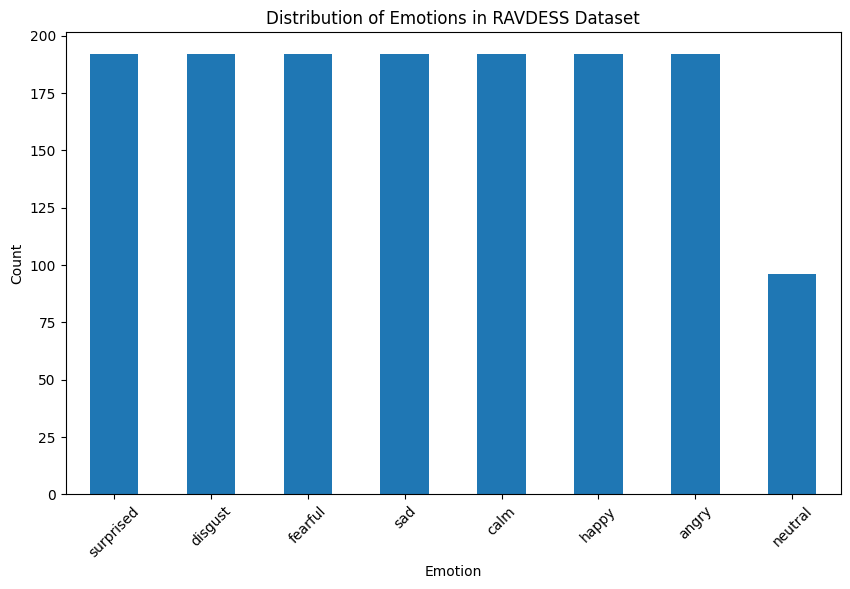

In [25]:

emotion_counts = df['emotion'].value_counts()
print(emotion_counts)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar')
plt.title('Distribution of Emotions in RAVDESS Dataset')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

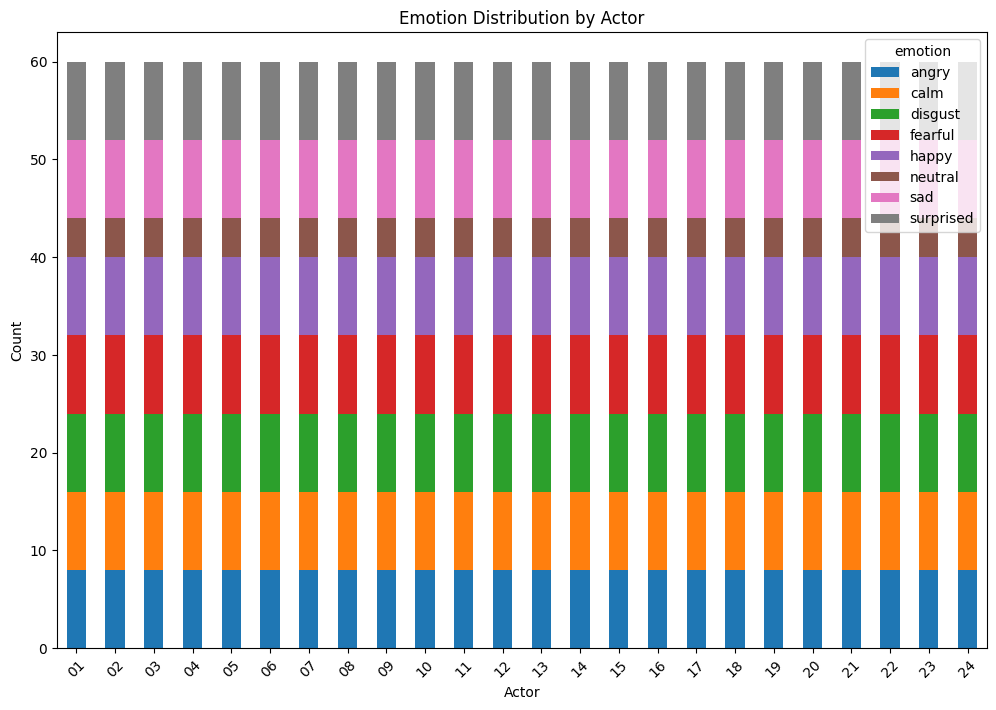

In [26]:

actor_emotion_counts = df.groupby('actor_id')['emotion'].value_counts().unstack()
actor_emotion_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Emotion Distribution by Actor')
plt.xlabel('Actor')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [27]:
print(df["file"][0])
import librosa
file_path = df["file_path"][0]
audio, sr = librosa.load(file_path)  # audio: mảng tín hiệu, sr: tần số lấy mẫu

# In thông tin
print("Tín hiệu âm thanh:", audio)
print("Tần số lấy mẫu:", sr)

03-01-08-01-01-01-02.wav
Tín hiệu âm thanh: [ 0.0000000e+00  0.0000000e+00  0.0000000e+00 ...  3.3473766e-06
 -1.9576355e-06  1.3353035e-06]
Tần số lấy mẫu: 22050


In [28]:
import os
import pandas as pd
import numpy as np
import librosa
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from librosa.util import fix_length

# Đường dẫn dữ liệu RAVDESS
data_dir = "/kaggle/input/ravdess-emotional-speech-audio"

# Ánh xạ cảm xúc
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Hàm lọc nhiễu (low-pass filter)
def butter_lowpass_filter(data, cutoff=4000, fs=16000, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='lowpass', analog=False)
    return lfilter(b, a, data)

# Tạo DataFrame từ RAVDESS
data = []
for actor_dir in os.listdir(data_dir):
    actor_path = os.path.join(data_dir, actor_dir)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")
                emotion_code = parts[2]
                emotion_label = emotion_map.get(emotion_code, "unknown")
                parts = actor_dir.split("_")
                actor_id = parts[1]
                file_path = os.path.join(actor_path, file)
                data.append({
                    "file": file,
                    "emotion": emotion_label,
                    "actor_id": actor_id,
                    "file_path": file_path
                })
df = pd.DataFrame(data)

# Thêm cột data_raw (tín hiệu thô)
df['data_raw'] = None  # Khởi tạo cột
for idx, row in df.iterrows():
    audio, sr = librosa.load(row['file_path'], sr=16000)
    df.at[idx, 'data_raw'] = audio

# Tiền xử lý dữ liệu thô: Lọc nhiễu + Chuẩn hóa biên độ
for idx, row in df.iterrows():
    audio = row['data_raw']
    # Lọc nhiễu (low-pass filter)
    audio_denoised = butter_lowpass_filter(audio)
    # Chuẩn hóa biên độ
    audio_normalized = audio_denoised / (np.max(np.abs(audio_denoised)) + 1e-6)
    df.at[idx, 'data_raw'] = audio_normalized

# Trích xuất đặc trưng MFCC
df['data_ex'] = None  # Khởi tạo cột
for idx, row in df.iterrows():
    audio = row['data_raw']
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    df.at[idx, 'data_ex'] = mfcc

# Tiền xử lý đặc trưng MFCC: Làm mịn, Chuẩn hóa, Giảm chiều, Padding
df['data_fi'] = None  # Khởi tạo cột
scaler = StandardScaler()
pca = PCA(n_components=10)  # Giảm chiều về 10
max_frames = 100  # Số khung tối đa cho padding
for idx, row in df.iterrows():
    mfcc = row['data_ex']
    # Làm mịn (moving average)
    mfcc_smoothed = np.apply_along_axis(
        lambda x: np.convolve(x, np.ones(3)/3, mode='same'), axis=1, arr=mfcc
    )
    # Chuẩn hóa
    mfcc_normalized = scaler.fit_transform(mfcc_smoothed.T).T
    # Giảm chiều
    mfcc_reduced = pca.fit_transform(mfcc_normalized.T).T
    # Padding
    mfcc_padded = fix_length(mfcc_reduced, size=max_frames, axis=1)
    df.at[idx, 'data_fi'] = mfcc_padded

# In mẫu DataFrame
print("Sample DataFrame:")
print(df[['file', 'emotion', 'data_raw', 'data_ex', 'data_fi']].head())


Sample DataFrame:
                       file    emotion  \
0  03-01-08-01-01-01-02.wav  surprised   
1  03-01-01-01-01-01-02.wav    neutral   
2  03-01-07-02-01-02-02.wav    disgust   
3  03-01-07-01-01-02-02.wav    disgust   
4  03-01-01-01-02-01-02.wav    neutral   

                                            data_raw  \
0  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
1  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
2  [-1.0439948176984293e-14, -5.498372706545061e-...   
3  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...   
4  [2.2071092002560074e-14, 9.729297699087707e-14...   

                                             data_ex  \
0  [[-554.0108429502741, -554.0108429502741, -554...   
1  [[-574.1709788751353, -574.1709788751353, -574...   
2  [[-581.2692819197939, -581.2692819197939, -581...   
3  [[-578.3648867783379, -578.3648867783379, -578...   
4  [[-585.6209951003123, -585.6209951003123, -585...   

                                             data_fi  


In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input


In [30]:

# Chuẩn bị dữ liệu từ DataFrame
X = np.stack(df['data_fi'].values)  # Chuyển data_fi thành mảng 3D (số mẫu, 10, 100)
X = X[:, :, :, np.newaxis]  # Thêm chiều kênh: (số mẫu, 10, 100, 1) cho CNN

# Mã hóa nhãn
le = LabelEncoder()
y = le.fit_transform(df['emotion'])
y = to_categorical(y, num_classes=8)  # One-hot encoding: 8 lớp

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình CNN
model = Sequential([
    Input(shape=(10, 100, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 lớp cảm xúc
])

# Biên dịch mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# In tóm tắt mô hình
model.summary()

# Huấn luyện mô hình
history = model.fit(X_train, y_train, epochs=200, batch_size=16, validation_data=(X_test, y_test))

# Đánh giá mô hình
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 8, 98, 32)           │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 49, 32)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 2, 47, 64)           │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 1, 23, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1472)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         188,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 208,392 (814.03 KB)

 Trainable params: 208,392 (814.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1100 - loss: 2.1155 - val_accuracy: 0.2083 - val_loss: 2.0525
Epoch 2/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2093 - loss: 2.0377 - val_accuracy: 0.1979 - val_loss: 1.9969
Epoch 3/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2108 - loss: 1.9856 - val_accuracy: 0.2431 - val_loss: 1.9371
Epoch 4/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2516 - loss: 1.9126 - val_accuracy: 0.2292 - val_loss: 1.9479
Epoch 5/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2780 - loss: 1.8695 - val_accuracy: 0.2361 - val_loss: 1.9366
Epoch 6/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3332 - loss: 1.7950 - val_accuracy: 0.2188 - val_loss: 1.9377
Epoch 7/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3369 - loss: 1.7606 - val_accuracy: 0.2257 - val_loss: 1.9277
Epoch 8/200
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4388 - loss: 1.6107 - val_accuracy: 0.

In [40]:
X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

y_train_rf = np.argmax(y_train, axis=1)
y_test_rf = np.argmax(y_test, axis=1)

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_rf, y_train_rf)

y_pred = rf.predict(X_test_rf)

print("Accuracy:", accuracy_score(y_test_rf, y_pred))
print(classification_report(y_test_rf, y_pred))

Accuracy: 0.3020833333333333
              precision    recall  f1-score   support

           0       0.34      0.41      0.37        34
           1       0.30      0.33      0.31        40
           2       0.33      0.40      0.36        45
           3       0.23      0.35      0.28        31
           4       0.24      0.17      0.20        41
           5       0.00      0.00      0.00        19
           6       0.25      0.20      0.22        35
           7       0.38      0.40      0.39        43

    accuracy                           0.30       288
   macro avg       0.26      0.28      0.27       288
weighted avg       0.28      0.30      0.29       288



In [43]:
X_train_ml = X_train.reshape(X_train.shape[0], -1)
X_test_ml = X_test.reshape(X_test.shape[0], -1)

y_train_ml = np.argmax(y_train, axis=1)
y_test_ml = np.argmax(y_test, axis=1)

In [44]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1, gamma='scale')

svm.fit(X_train_ml, y_train_ml)

y_pred = svm.predict(X_test_ml)

print(accuracy_score(y_test_ml, y_pred))
print(classification_report(
    y_test_ml,
    y_pred,
    target_names=le.classes_
))

0.2743055555555556
              precision    recall  f1-score   support

       angry       0.23      0.26      0.25        34
        calm       0.29      0.35      0.32        40
     disgust       0.29      0.27      0.28        45
     fearful       0.22      0.23      0.22        31
       happy       0.32      0.24      0.28        41
     neutral       0.00      0.00      0.00        19
         sad       0.18      0.20      0.19        35
   surprised       0.35      0.47      0.40        43

    accuracy                           0.27       288
   macro avg       0.23      0.25      0.24       288
weighted avg       0.26      0.27      0.26       288



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [45]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_ml, y_train_ml)

y_pred = knn.predict(X_test_ml)

print(accuracy_score(y_test_ml, y_pred))
print(classification_report(
    y_test_ml,
    y_pred,
    target_names=le.classes_
))

0.2465277777777778
              precision    recall  f1-score   support

       angry       0.20      0.24      0.21        34
        calm       0.28      0.47      0.36        40
     disgust       0.32      0.20      0.25        45
     fearful       0.20      0.23      0.21        31
       happy       0.27      0.32      0.29        41
     neutral       0.21      0.21      0.21        19
         sad       0.11      0.06      0.07        35
   surprised       0.30      0.21      0.25        43

    accuracy                           0.25       288
   macro avg       0.24      0.24      0.23       288
weighted avg       0.24      0.25      0.24       288

